### Loading the data

In [ ]:
from matplotlib.pyplot import plot_date
from scipy.fft import fft
from sympy.stats.sampling.sample_scipy import scipy
from src.utils.data_reading.sound_data.sound_file_manager import DatFilesManager, WFilesManager
from utils.data_reading.sound_data.station import StationsCatalog
import os
from utils.physics.sound_model.ellipsoidal_sound_model import GridEllipsoidalSoundModel
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import numpy as np
import glob2
import datetime
from matplotlib.colors import ListedColormap
import colorcet as cc
from datetime import timedelta, tzinfo, timezone
import pickle
from pathlib import Path
from utils.physics.signal.make_spectrogram import make_spectrogram
from tqdm import tqdm

In [ ]:
# paths
CATALOG_PATH = "/media/rsafran/CORSAIR/OHASISBIO/recensement_stations_OHASISBIO_RS_V2.csv"  # csv catalog files
DETECTIONS_DIR = "/media/rsafran/CORSAIR/T-pick_2.2"  # where we have detection pickles
ISAS_PATH = "/media/rsafran/CORSAIR/ISAS/extracted/2018"
YEAR = 2018
 # output dir
ASSOCIATIONS_DIR = f"../../data/detection/T-pick_2.2/{YEAR}"
file_end=''#'_SWIR_crise_10'
# ASSOCIATIONS_DIR = f"../../data/detection/H-pick_MAHY/{YEAR}"
# DETECTIONS_DIR = "/media/rsafran/CORSAIR/H-pick_MAHY"
# file_end= '_impulsive_MAHY'
Path(ASSOCIATIONS_DIR).mkdir(exist_ok=True)

# delimitation of the detections we keep (this notebook actually associates the detections of 1 year and 4 hours)
DATE_START = datetime.datetime(YEAR, 1, 1) - datetime.timedelta(hours=2)
DATE_END = datetime.datetime(YEAR+1, 3, 1) + datetime.timedelta(hours=2)
#crise
# DATE_START = datetime.datetime(YEAR, 7, 10) - datetime.timedelta(hours=2)
# DATE_END = datetime.datetime(YEAR+1, 7, 15) + datetime.timedelta(hours=2)

# Detections loading parameters
MIN_P_TISSNET_PRIMARY = 0.5 # min probability of browsed detections
MIN_P_TISSNET_SECONDARY = 0.1  # min probability of detections that can be associated with the browsed one
MERGE_DELTA_S = 1# threshold below which we consider two events should be merged

# The REQ_CLOSEST_STATIONS th closest stations will be required for an association to be valid
# e.g. if we set it to 6, no association of size <6 will be saved (this is useful to save memory)
REQ_CLOSEST_STATIONS = 6

# sound model definition

arr = os.listdir(ISAS_PATH)
file_list = [os.path.join(ISAS_PATH, fname) for fname in arr if fname.endswith('.nc')]
SOUND_MODEL = GridEllipsoidalSoundModel(file_list)
STATIONS = StationsCatalog(CATALOG_PATH).filter_out_undated().filter_out_unlocated()


In [ ]:
Path(f"{ASSOCIATIONS_DIR}/cache").mkdir(parents=True, exist_ok=True)
DET_PATH = f"{ASSOCIATIONS_DIR}/cache/detections_{MIN_P_TISSNET_SECONDARY}_{MERGE_DELTA_S}{file_end}.pkl"
with open(DET_PATH, "rb") as f:
    DETECTIONS = pickle.load(f)

In [ ]:
# do not keep detection entries for which the detection list is empty
to_del = []
for s in DETECTIONS.keys():
    if len(DETECTIONS[s]) == 0:
        to_del.append(s)
    if s.name == 'H04S1':# or s.name == 'H04N1' or s.name == 'H01W1':
        to_del.append(s)
for s in to_del:
    del DETECTIONS[s]

# assign an index to each detection
idx_det = 0
IDX_TO_DET = {}
for idx, s in enumerate(DETECTIONS.keys()):
    s.idx = idx  # indexes to store efficiently the associations
    DETECTIONS[s] = list(DETECTIONS[s])
    for i in range(len(DETECTIONS[s])):
        DETECTIONS[s][i] = np.concatenate((DETECTIONS[s][i], [idx_det]))
        IDX_TO_DET[idx_det] = DETECTIONS[s][i]
        idx_det += 1
    DETECTIONS[s] = np.array(DETECTIONS[s])
DETECTION_IDXS = np.array(list(range(idx_det)))

# only keep the stations that appear in the kept detections
STATIONS = [s for s in DETECTIONS.keys()]
FIRSTS_DETECTIONS = {s : DETECTIONS[s][0,0] for s in STATIONS}
LASTS_DETECTIONS = {s : DETECTIONS[s][-1,0] for s in STATIONS}

In [ ]:
# RL_PATH = f"{ASSOCIATIONS_DIR}/cache/rl_{MIN_P_TISSNET_SECONDARY}_{MERGE_DELTA_S}{file_end}.pkl"
# with open(RL_PATH, "rb") as f:
#     IDX_TO_RL = pickle.load(f)

In [ ]:
files = glob2.glob(f"{DETECTIONS_DIR}/cache/associations_2018{file_end}.pkl")
with open(files[0], "rb") as f:
    associations = pickle.load(f)
    print(len(associations))
# associations = associations[:5000]
# #
# def process(i):
#     station = list(map(lambda j: STATIONS[j].get_pos(), associations[i][0][:,0]))
#
#     if len(station) < 7:
#         return None
#
#     det = list(map(lambda j: IDX_TO_DET[j][0], associations[i][0][:,1]))

In [ ]:
with open(f"{DETECTIONS_DIR}/cache/filtered_results_2018{file_end}.pkl", "rb") as f:
        final_results = pickle.load(f)

In [ ]:
final_results

In [ ]:
#exemple pour aller chercher les détéctions times d'un événement
def process(i,RL=False):
    station = list(map(lambda j: STATIONS[j], associations[i][0][:,0]))

    # if len(station) < 7:
    #     return None

    det = list(map(lambda j: IDX_TO_DET[j][0], associations[i][0][:,1]))
    if RL :
        RL = list(map(lambda k : IDX_TO_RL[k][0], associations[i][0][:,1]))
        NL = list(map(lambda k : IDX_TO_RL[k][1], associations[i][0][:,1]))
        return station,det, RL, NL

    return(station, det)



In [ ]:
# Root directory containing subfolders for each station
DATA_ROOT = "/media/rsafran/CORSAIR/OHASISBIO"
# Subfolder (e.g. year) within DATA_ROOT
DATASET   = "OHASISBIO-2018"


def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs):
    b, a = butter_bandpass(lowcut, highcut, fs)
    y = filtfilt(b, a, data)
    return y


def refine_single_detection(station_obj, det_time, lowcut=None, highcut=None,timedelta_min=5):
    """
    Refine one pick time by locating the max energy within ±SMOOTH_WINDOW_SEC.
    Also computes a simple SNR ratio.
    Returns a dict or None on failure.
    """
    # load waveform ±3 minutes
    start = det_time - timedelta(minutes=timedelta_min)
    end   = det_time + timedelta(minutes=timedelta_min)
    if station_obj.dataset=="OHASISBIO-2018":
        raw = 'raw'
        mgr = DatFilesManager(f"{DATA_ROOT}/{DATASET}/{station_obj.name}", kwargs=raw)
        data = mgr.get_segment(start, end)
        sampling_f = mgr.sampling_f
    else :
        mgr = WFilesManager(f"/media/rsafran/CORSAIR/CTBT/CTBTO_2018/{station_obj.name}_2018/")
        data = mgr.get_segment(start, end)
        sampling_f = round(mgr.sampling_f)

    n = len(data)
    t = np.arange(n) / sampling_f - (det_time - start).total_seconds()
    if lowcut is not None and highcut is not None:
        data = bandpass_filter(data,lowcut, highcut, round(sampling_f))

    return data,t, sampling_f

In [ ]:
def plot_data(t,data,sampling_f,station_obj=None):
    plt.figure(figsize=(16,9))

    # plt.plot(t[::240],data[::240],alpha=0.7,linewidth=0.5,label=station_obj.name)
    f, t, spectro = make_spectrogram(data, sampling_f, t_res=0.25, f_res=0.25, return_bins=True, normalize=False, vmin=40, vmax=120)
    plt.imshow(spectro, aspect="auto", cmap="inferno", extent=(t[0], t[-1], f[0], f[-1]))
    plt.axvline(300)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar()
    if station_obj :
        plt.title(station_obj.name)
        plt.savefig(f'/home/rsafran/Images/Spectrogram/{station_obj.name}.png')

def plot_energy(data,sampling_f):
    # Paramètres

    lowcut = 1  # Fréquence de coupure basse (Hz)
    highcut = 110  # Fréquence de coupure haute (Hz)
    window_size = 5  # Taille de la fenêtre en secondes
    fs = round(sampling_f)
    # Fonction pour appliquer le filtre passe-bande
    def butter_bandpass(lowcut, highcut, fs, order=4):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    def bandpass_filter(data, lowcut, highcut, fs):
        b, a = butter_bandpass(lowcut, highcut, fs)
        y = filtfilt(b, a, data)
        return y

    # Appliquer le filtre
    filtered_data = data #bandpass_filter(data, lowcut, highcut, fs)

    # Découpage en fenêtres et calcul du SPL
    samples_per_window = window_size * fs
    num_windows = int(len(filtered_data) / samples_per_window)
    SPL_windows = np.zeros(num_windows)
    time_windows = np.zeros(num_windows)

    for i in range(num_windows):
        start_idx = i * samples_per_window
        end_idx = start_idx + samples_per_window
        window = filtered_data[start_idx:end_idx]

        # Calcul de la valeur RMS
        P_RMS = np.sqrt(np.mean(np.square(window)))

        # Calcul du SPL
        P_ref = 1e-6
        SPL = 20 * np.log10(P_RMS / P_ref)
        SPL_windows[i] = SPL

        # Temps central de la fenêtre (en secondes)
        time_windows[i] = (start_idx + end_idx) / (2 * fs)

    # Visualisation
    # plt.figure(figsize=(12, 6))
    plt.plot(time_windows, SPL_windows, marker='o', linestyle='-')
    # plt.xlabel("Temps (s)")
    # plt.ylabel("SPL (dB re 1 μPa)")
    # plt.title("Évolution du SPL (0.6–20 Hz) par fenêtres de 30 secondes")
    # plt.grid(True)
    # plt.show()


import matplotlib.pyplot as pl

def plot_energy_bis(data,sampling_f):
    # Fonction pour créer un filtre passe-bande
    def butter_bandpass(lowcut, highcut, fs, order=4):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    def bandpass_filter(data, lowcut, highcut, fs):
        b, a = butter_bandpass(lowcut, highcut, fs)
        y = filtfilt(b, a, data)
        return y

    # Paramètres
    fs = round(sampling_f) # Fréquence d'échantillonnage (à adapter)
    window_size = 30 * fs  # Taille de la fenêtre en échantillons (30 secondes)
    window_step = 15 * fs  # Pas entre les fenêtres (sans chevauchement ici)

    # Définir les bandes de tiers d'octave
    center_frequencies = np.array([ 1.25, 1.6, 2.0, 2.5, 3.15, 4.0, 5.0, 6.3, 8.0, 10.0, 12.5, 16.0, 20.0,26,30,35,40])
    bandwidth = 1/3  # Bande de tiers d'octave
    lowcuts = center_frequencies / (2 ** (bandwidth/2))
    highcuts = center_frequencies * (2 ** (bandwidth/2))

    # Découper le signal en fenêtres temporelles
    num_windows = int((len(data) - window_size) / window_step) + 1
    time_centers = np.array([(i * window_step + window_size/2) / fs for i in range(num_windows)])

    # Initialiser un tableau pour stocker les énergies
    energies = np.zeros((len(center_frequencies), num_windows))

    # Calculer l'énergie pour chaque fenêtre et chaque bande
    for i in range(num_windows):
        start_idx = i * window_step
        end_idx = start_idx + window_size
        window = data[start_idx:end_idx]

        for j, (lowcut, highcut) in enumerate(zip(lowcuts, highcuts)):
            filtered_window = bandpass_filter(window, lowcut, highcut, fs)
            energy = np.sum(filtered_window**2) / fs  # Énergie normalisée
            energies[j, i] = energy
    colors = pl.cm.jet(np.linspace(0,1,20))
    # Visualiser l'évolution temporelle de l'énergie pour chaque bande
    plt.figure(figsize=(14, 8))
    for j, freq in enumerate(center_frequencies):
        plt.plot(time_centers, energies[j, :], label=f'{freq} Hz',color=colors[j])
        plt.yscale('log')
        # plt.xscale('log')

    plt.xlabel("Temps (s)")
    plt.ylabel("Énergie")
    plt.title("Évolution temporelle de l'énergie par bande de tiers d'octave")
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.show()



In [ ]:
station_obj = process(16955)[0][0]
det_time = process(16955)[1][0]
data,t, sampling_f = refine_single_detection(station_obj, det_time)
plot_data(t,data,sampling_f,station_obj)
print(det_time)

In [ ]:
plt.figure(figsize=(21, 12))

for i in range(len(process(k)[0])):
    station_obj = process(k)[0][i]
    det_time = process(k)[1][i]
    print(det_time)
    data,t, sampling_f = refine_single_detection(station_obj, det_time)
    # print(np.median(data))
    data = (data - np.mean(data)/np.std(data))
    plot_data(t,data,sampling_f,station_obj)
    # plot_energy(data,sampling_f)
    # plot_energy_bis(data,sampling_f)
    # plot_rl_estimators(data, sampling_f,
    #                    lowcut=0.6, highcut=6,
    #                    window_sec=5,
    #                    step_sec=5, station_obj=station_obj)
plt.legend()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

P_REF = 1e-6  # 1 µPa

def plot_rl_estimators(data, sampling_f,
                       lowcut=5, highcut=30,
                       window_sec=15,
                       step_sec=10,station_obj=None):

    fs = round(sampling_f)
    t = np.arange(len(data)) / fs

    # -------------------------
    # 1. Filtrage 5–30 Hz
    # -------------------------
    def butter_bandpass(lowcut, highcut, fs, order=4):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    b, a = butter_bandpass(lowcut, highcut, fs)
    data_filt = data#filtfilt(b, a, data)

    # -------------------------
    # 2. Fenêtres glissantes
    # -------------------------
    win = int(window_sec * fs)
    step = int(step_sec * fs)

    nwin = int((len(data) - win) / step) + 1
    time_centers = np.zeros(nwin)

    SPL_RMS = np.zeros(nwin)
    SEL = np.zeros(nwin)
    BANDPOWER = np.zeros(nwin)

    for i in range(nwin):
        start = i * step
        end = start + win
        window = data_filt[start:end]
        time_centers[i] = (start/fs)# + end) / (2 * fs)

        # --- RMS ---
        p_rms = np.sqrt(np.mean(window**2))
        SPL_RMS[i] = 20 * np.log10(p_rms / P_REF)

        # --- SEL ---
        integral = np.sum(window**2) / fs
        SEL[i] = 10 * np.log10(integral / (P_REF**2))

        # --- Band power via PSD (Welch) ---
        freqs, psd = welch(window, fs=fs, nperseg=min(len(window), fs*2))
        mask = (freqs >= lowcut) & (freqs <= highcut)
        band_power = np.trapezoid(psd[mask], freqs[mask])
        BANDPOWER[i] = 10 * np.log10(band_power / (P_REF**2))
    noise_level = np.median(SEL)
    SEL = SEL #np.log10(10**SEL/10**noise_level)
    BANDPOWER = np.log10(10**BANDPOWER/ 10**np.median(BANDPOWER))
    SPL_RMS = np.log10(10**SPL_RMS / 10**np.median(SPL_RMS))
    # -------------------------
    # 3. Affichage
    # -------------------------


    # # Signal brut
    # ax1 = plt.subplot(3,1,1)
    # ax1.plot(t, data)
    # ax1.set_title("Signal brut")
    # ax1.set_ylabel("Pa")

    # Signal filtré
    # ax2 = plt.subplot(2,1,1)
    # ax2.plot(t, data_filt)
    # ax2.set_title("Signal filtré 5–30 Hz")
    # ax2.set_ylabel("Pa")

    # Estimateurs
    ax3 = plt.subplot(2,1,2)
    # ax3.plot(time_centers, SPL_RMS, label=f"SPL RMS (dB re 1µPa) {station_obj.name}")
    ax3.plot(time_centers, SEL, label=f"SEL (dB re 1µPa²·s) {station_obj.name}")
    # ax3.plot(time_centers, BANDPOWER, label=f"BandPower (dB re 1µPa²) {station_obj.name}")
    ax3.set_ylabel("dB")
    ax3.set_title("Estimateurs RL (5–30 Hz)")
    ax3.legend()
    ax3.grid()

    # # Spectrogramme
    # ax4 = plt.subplot(4,1,4)
    # plt.specgram(data, Fs=fs, NFFT=2048, noverlap=1024)
    # plt.ylim(0, 50)
    # ax4.set_title("Spectrogramme")
    # ax4.set_xlabel("Temps (s)")
    # ax4.set_ylabel("Fréquence (Hz)")

    plt.tight_layout()



In [ ]:
def compute_RL(data, fs, window_sec=10, step_sec=1,signal_margin_sec=5,plot=False):
    """
    Calcule le SPL sur fenêtres glissantes et extrait le SPL du signal et le niveau de bruit.

    Parameters:
    -----------
    data : array
        Signal temporel (le signal d'intérêt COMMENCE au milieu)
    fs : float
        Fréquence d'échantillonnage
    window_sec : float
        Durée de la fenêtre d'analyse (secondes)
    step_sec : float
        Pas de glissement (secondes)
    signal_margin_sec : float
        Marge de sécurité autour du signal (secondes)

    Returns:
    --------
    SPL_RMS : array
        Tous les SPL calculés
    time_centers : array
        Temps correspondant à chaque fenêtre
    SPL_signal_max : float
        SPL maximum dans la zone du signal
    noise_level : float
        Niveau de bruit médian (hors signal)
    """

    P_REF = 1e-6

    # -------------------------
    # Fenêtres glissantes
    # -------------------------
    win = int(window_sec * fs)
    step = int(step_sec * fs)
    nwin = int((len(data) - win) / step) + 1

    time_centers = np.zeros(nwin)
    SPL_RMS = np.zeros(nwin)

    for i in range(nwin):
        start = i * step
        end = start + win
        window = data[start:end]
        time_centers[i] = (start) / fs

        # --- RMS ---
        p_rms = np.sqrt(np.mean(window**2))
        SPL_RMS[i] = 20 * np.log10(p_rms / P_REF)

    # -------------------------
    # Identification des zones (asymétrique)
    # -------------------------
    total_duration = len(data) / fs
    signal_start_time = total_duration/2  # Le signal COMMENCE au début


    # Zone étendue avec marges de sécurité
    signal_zone_start = signal_start_time - signal_margin_sec
    signal_zone_end = signal_start_time + window_sec+signal_margin_sec

    # Masques booléens
    is_signal = (time_centers >= signal_zone_start) & (time_centers <= signal_zone_end)
    is_noise = ~is_signal

    # -------------------------
    # Extraction des niveaux
    # -------------------------
    # SPL maximum dans la zone du signal
    if np.any(is_signal):
        SPL_signal_max = np.max(SPL_RMS[is_signal])
    else:
        SPL_signal_max = np.nan
        print("Attention : aucune fenêtre dans la zone du signal")

    # Niveau de bruit (médiane hors signal)
    if np.any(is_noise):
        noise_level = np.median(SPL_RMS[is_noise])
    else:
        noise_level = np.nan
        print("Attention : aucune fenêtre de bruit disponible")

    SPL_RMS =SPL_RMS-noise_level
    SPL_signal_max = SPL_signal_max-noise_level
    noise_level =0
    if plot :
        total_duration = len(data) / sampling_f
        signal_start = total_duration / 2

        # plt.figure(figsize=(14, 6))
        plt.plot(time_centers, SPL_RMS, linewidth = 0.5,alpha=1, label='SPL')
        plt.plot(time_centers[is_signal], SPL_RMS[is_signal], 'r+', linewidth=2,alpha=0.8, label='Zone signal')

        # # Ligne verticale au début du signal
        # plt.axvline(signal_start, color='orange', linestyle=':', linewidth=2, label='Début signal (milieu data)')
        #
        # plt.axhline(noise_level, color='g', linestyle='--', label=f'Bruit médian: {noise_level:.1f} dB')
        # plt.axhline(SPL_signal_max, color='r', linestyle='--', label=f'SPL max: {SPL_signal_max:.1f} dB')

        plt.xlabel('Temps (s)')
        plt.ylabel('SPL (dB re 1 µPa)')
        plt.title('Analyse SPL - Signal commence au milieu de data')
        # plt.legend()
        plt.grid(True, alpha=0.3)
        # plt.show()

    return SPL_RMS, time_centers, SPL_signal_max, noise_level, is_signal


# -------------------------
# UTILISATION
# -------------------------
SPL_RMS, time_centers, SPL_signal_max, noise_level, signal_mask = compute_RL(
    data,
    sampling_f,
    window_sec=30,
    step_sec=1,
    signal_margin_sec=2      # Marge de sécurité
)

print(f"SPL max du signal : {SPL_signal_max:.1f} dB")
print(f"Niveau de bruit : {noise_level:.1f} dB")
print(f"SNR : {SPL_signal_max - noise_level:.1f} dB")

# -------------------------
# VISUALISATION
# -------------------------
import matplotlib.pyplot as plt

total_duration = len(data) / sampling_f
signal_start = total_duration / 2

plt.figure(figsize=(14, 6))
plt.plot(time_centers, SPL_RMS, 'b-', alpha=0.7, label='SPL')
plt.plot(time_centers[signal_mask], SPL_RMS[signal_mask], 'r-', linewidth=2, label='Zone signal')

# Ligne verticale au début du signal
plt.axvline(signal_start, color='orange', linestyle=':', linewidth=2, label='Début signal (milieu data)')

plt.axhline(noise_level, color='g', linestyle='--', label=f'Bruit médian: {noise_level:.1f} dB')
plt.axhline(SPL_signal_max, color='r', linestyle='--', label=f'SPL max: {SPL_signal_max:.1f} dB')

plt.xlabel('Temps (s)')
plt.ylabel('SPL (dB re 1 µPa)')
plt.title('Analyse SPL - Signal commence au milieu de data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
fig = plt.figure(figsize=(16, 12))
for i in range(len(process(k)[0])):
    station_obj = process(k)[0][i]
    det_time = process(k)[1][i]
    data,t, sampling_f = refine_single_detection(station_obj, det_time, lowcut=5, highcut=100)
    # plot_rl_estimators(data, sampling_f,
    #                        lowcut=2, highcut=30,
    #                        window_sec=10,
    #                        step_sec=1,station_obj=station_obj)
    compute_RL(data,
    sampling_f,
    window_sec=10,
    step_sec=1,
    signal_margin_sec=2, plot=True)
plt.show()

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed

def refine_single_detection(station_obj, det_time, lowcut=None, highcut=None):
    """
    Refine one pick time by locating the max energy within ±SMOOTH_WINDOW_SEC.
    Also computes a simple SNR ratio.
    Returns a dict or None on failure.
    """
    # load waveform ±3 minutes
    start = det_time - timedelta(minutes=5)
    end   = det_time + timedelta(minutes=5)
    if station_obj.dataset=="OHASISBIO-2018":
        raw = 'raw'
        mgr = DatFilesManager(f"{DATA_ROOT}/{DATASET}/{station_obj.name}", kwargs=raw)
        data = mgr.get_segment(start, end)
        sampling_f = mgr.sampling_f
    else :
        mgr = WFilesManager(f"/media/rsafran/CORSAIR/CTBT/CTBTO_2018/{station_obj.name}_2018/")
        data = mgr.get_segment(start, end)
        sampling_f = round(mgr.sampling_f)

    n = len(data)
    t = np.arange(n) / sampling_f - (det_time - start).total_seconds()
    if lowcut is not None and highcut is not None:
        data = bandpass_filter(data,lowcut, highcut, round(sampling_f))

    return data,t, sampling_f


def compute_RL(data, fs, window_sec=10, step_sec=1, signal_margin_sec=5):

    P_REF = 1e-6

    # -------------------------
    # Fenêtres glissantes
    # -------------------------
    win = int(window_sec * fs)
    step = int(step_sec * fs)
    nwin = int((len(data) - win) / step) + 1

    time_centers = np.zeros(nwin)
    SPL_RMS = np.zeros(nwin)

    for i in range(nwin):
        start = i * step
        end = start + win
        window = data[start:end]
        time_centers[i] = (start) / fs

        # --- RMS ---
        p_rms = np.sqrt(np.mean(window**2))
        SPL_RMS[i] = 20 * np.log10(p_rms / P_REF)

    # -------------------------
    # Identification des zones (asymétrique)
    # -------------------------
    total_duration = len(data) / fs
    signal_start_time = total_duration/2  # Le signal COMMENCE au début


    # Zone étendue avec marges de sécurité
    signal_zone_start = signal_start_time - signal_margin_sec
    signal_zone_end = signal_start_time + window_sec+signal_margin_sec

    # Masques booléens
    is_signal = (time_centers >= signal_zone_start) & (time_centers <= signal_zone_end)
    is_noise = ~is_signal

    # -------------------------
    # Extraction des niveaux
    # -------------------------
    # SPL maximum dans la zone du signal
    if np.any(is_signal):
        SPL_signal_max = np.max(SPL_RMS[is_signal])
    else:
        SPL_signal_max = np.nan
        print("Attention : aucune fenêtre dans la zone du signal")

    # Niveau de bruit (médiane hors signal)
    if np.any(is_noise):
        noise_level = np.nanmedian(SPL_RMS[is_noise])
    else:
        noise_level = np.nan
        print("Attention : aucune fenêtre de bruit disponible")

    return SPL_signal_max, noise_level


# -------------------------------------------------------
# 1. Mapping inverse : idx_det → station
# -------------------------------------------------------
IDX_TO_STATION = {}
for s in STATIONS:
    for det in DETECTIONS[s]:
        idx_det = int(det[-1])          # dernier champ = index
        IDX_TO_STATION[idx_det] = s

# -------------------------------------------------------
# 2. Paramètres du filtre (adaptez selon vos données)
# -------------------------------------------------------
LOWCUT  = 5.0    # Hz
HIGHCUT = 100.0   # Hz
N_WORKERS = 20

# -------------------------------------------------------
# Fonction top-level (obligatoire pour pickle avec multiprocessing)
# -------------------------------------------------------
def process_one(args):
    idx_det, det, station, lowcut, highcut = args
    det_time = det[0]
    try:
        data, t, fs = refine_single_detection(station, det_time, lowcut=lowcut, highcut=highcut)
        spl_max, noise_level = compute_RL(data, fs)
        return idx_det, (spl_max, noise_level)
    except Exception as e:
        return idx_det, (np.nan, np.nan)

# -------------------------------------------------------
# Préparation des arguments (pas de globaux dans les workers)
# -------------------------------------------------------
det_idx = list(map(lambda k : list(associations[k][0][:,1]), final_results.keys()))

def flatten(xss):
    return [x for xs in xss for x in xs]

det_idx = flatten(det_idx)

args_list = [
    (idx, IDX_TO_DET[idx], IDX_TO_STATION[idx], LOWCUT, HIGHCUT)
    for idx in det_idx
]


# -------------------------------------------------------
# Exécution
# -------------------------------------------------------
IDX_TO_RL   = {}
FAILED_IDXS = []

with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(process_one, args): args[0] for args in args_list}
    with tqdm(total=len(futures), desc="Computing RL") as pbar:
        for future in as_completed(futures):
            idx_det, result = future.result()
            IDX_TO_RL[idx_det] = result
            if np.isnan(result[0]):
                FAILED_IDXS.append(idx_det)
            pbar.update(1)

print(f"Terminé. {len(IDX_TO_RL)} entrées, {len(FAILED_IDXS)} échecs.")

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, welch
from datetime import timedelta


def build_rl_dataframe(associations, event_list=None):
    """
    associations : dict-like mapping event_id -> list of station entries.
      - On gère deux formats usuels :
         1) associations[event_id] = [(station_obj, det_time), (station_obj2, det_time2), ...]
         2) associations[event_id] = [(station_name_or_id, det_time), ...]
      Si le format n'est pas celui-ci, on tente une retombée sur process(event_id) (si disponible).
    event_list : optionnel, liste d'event_id à traiter (par défaut toutes les clés de associations)
    Retour : pandas.DataFrame
    """
    rows = []
    for association_id in tqdm(event_list):
        asso_data = process(association_id,RL=True)
        for i in range(len(asso_data[0])):
            station_obj = asso_data[0][i]
            det_time = asso_data[1][i]
            RL = asso_data[2][i]
            NL = asso_data[3][i]
            station_id = associations[association_id][0][i,0]

            rows.append({
                'event_id': association_id,
                'station_id': station_id,
                'station_name': getattr(station_obj, 'name', None),
                'det_time': det_time,
                'SPL_RMS_dB' : RL,
                'Noise_level' : NL,
                })

    df = pd.DataFrame(rows)
    return df

df = build_rl_dataframe(associations,event_list=list(final_results.keys()))
print(df.head())


In [ ]:
from pyproj import Geod

bathy = {'NEAMS'   : 3840,
'MADW'     : 4848 ,
'SSWIR'    : 4390,
'MADE'     : 4018,
'SSEIR'    : 4180,
'RTJ'      : 3589,
'WKER2'    : 4536,
'H04N1'    : 548,
'ELAN'     : 4820 ,
'H08S1'    :1300 ,
'H01W1'    :1063.0  ,
'SWAMS-bot': 3433,
         'H04S1':550}

geod = Geod(ellps="WGS84")  # Utilise l'ellipsoïde WGS84
distances_df = []
for i in final_results.keys():
    names = list(map(lambda j: STATIONS[j].name, associations[i][0][:,0]))
    stations = list(map(lambda j: STATIONS[j].get_pos(include_depth=True), associations[i][0][:,0])) #lat lon stations
    stations = np.array(stations)
    vertical_dist = list(map(lambda j: bathy[STATIONS[j].name] - STATIONS[j].get_pos(include_depth=True)[2], associations[i][0][:,0]))
    pos = final_results[i].x[1::] #lat lon final event
    pos = np.array([pos]*len(stations))
    _, _, distances = geod.inv(pos[:,1], pos[:,0], stations[:,1], stations[:,0]) #lon lat
    distances_df.append({'event_id': i,
                         'station_name': names,
                         'vertical_dist': vertical_dist,
                         'distances': distances})

distances_df = pd.DataFrame(distances_df)
distances_df = distances_df.explode(['distances','vertical_dist',"station_name"])
df = df.merge(distances_df, how='left', on=['event_id','station_name'])

In [ ]:
df['distance_km'] = df['distances'] / 1000.0
df = df[df['distance_km'] > 0.1]  # éviter zone très proche
df['log10_r'] = df['distances'].apply(lambda x: np.log10(x))
df['20log10_rv'] = df['vertical_dist'].apply(lambda x: 20*np.log10(x))

In [ ]:
# df.loc[df['Noise_level']<0,["Noise_level"]]=200
df["SPL_RMS_dB_ns"]=20*np.log10(10**(df["SPL_RMS_dB"]/20)+
                                 10**(df['Noise_level']/20))
df["SPL_RMS_dB_nsv"]= 20*np.log10(10**(df["SPL_RMS_dB"]/20)+
                                 10**(df['Noise_level']/20)) + df['20log10_rv']


df["SNR_dB"]= df["SPL_RMS_dB"]-df['Noise_level']
df["SNR_dB_v"]= df["SPL_RMS_dB"]-df['Noise_level']+df['20log10_rv']
df["SPL_RMS_dB_v"]= df["SPL_RMS_dB"]+df['20log10_rv']

df['SL']= df['SPL_RMS_dB']+10*df['log10_r']
# Replacing infinite with nan
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Dropping all the rows with nan values
df.dropna(inplace=True)

# Printing df
df

In [ ]:
# df = df[(df['station_name']!='SWAMS-bot')& (df['station_name']!='NEAMS')]
df[(df['station_name']=='ELAN')]
ids = df[(df['station_name']=='ELAN')].event_id.values
lat = []
lon = []
for ids_ in ids :
    res = final_results[ids_]
    lat.append(res.x[1])
    lon.append(res.x[2])

plt.scatter(lon,lat)

In [ ]:
RL_COL = 'SPL_RMS_dB'  # recommandé 'SPL_RMS_dB', 'SEL_dB', 'Dziak_PSD_mean_dB','BandPower_dB', 'SPL_PP_dB', 'TPEF_dB', 'PSD_P90_dB', 'F_dom_Hz','F_centroid_Hz', 'TercileBandPower_dB',


In [ ]:
from scipy.stats import linregress
import statsmodels.api as sm
results = []

for ev in df['event_id'].unique():
    subset = df[df['event_id'] == ev].dropna(subset=[RL_COL])

    if len(subset) < 5:
        continue

    x = subset['log10_r'].values
    y = subset[RL_COL].values
    w=subset['SNR_dB_v'].values
    w=np.clip(w,0.1,None)
    # slope, intercept, r_value, p_value, std_err = linregress(x, y)
    #


    X = sm.add_constant(x)
    wls = sm.WLS(y, X, weights=w).fit()

    slope = wls.params[1]
    intercept = wls.params[0]
    r_value = np.sqrt(wls.rsquared)
    # print(wls.summary())

    results.append({
        'event_id': ev,
        'n_stations': len(subset),
        'intercept': intercept,
        'slope_dB_per_decade': slope,
        'R2': r_value**2
    })

summary_df = pd.DataFrame(results)
print(summary_df.describe())


plt.figure(figsize=(8,5))
plt.hist(summary_df['slope_dB_per_decade'], bins=20)
plt.axvline(-10, color='red', linestyle='--', label='Cylindrique')
plt.axvline(-20, color='green', linestyle='--', label='Sphérique')
plt.xlabel("Slope (dB per decade)")
plt.xlim((-30,15))
plt.ylabel("Count")
plt.legend()
plt.title(f"Distribution des pentes RL vs distance {RL_COL}")
plt.show()


# RL_COL = 'BandPower_dB'
plt.figure(figsize=(8,6))

df['RL_centered'] = (
    df[RL_COL] - df.groupby('event_id')[RL_COL].transform('median')
    # - df["Noise_level"] #df.groupby('event_id')[RL_COL].transform('median')
)
# Utilise l'intercept de la régression comme référence (RL à 1 km)
# df['RL_centered'] = df[RL_COL] - df['event_id'].map(
#     summary_df.set_index('event_id')['intercept']  # à ajouter dans results
# )

# for ev in df['event_id'].unique():
#     subset = df[df['event_id']==ev]
#     plt.scatter(subset['distance_km'], subset['RL_centered'],c=subset['station_id'],cmap= cm,norm=norm,alpha=0.8,)

# Créer une colormap personnalisée
unique_stations = sorted(df['station_id'].unique())
n_stations = len(unique_stations)
palette = cc.glasbey[:n_stations]
cmap = ListedColormap(palette)

#Plot result
s_min, s_max = 1, 150  # taille en points^2, à ajuster
snr = df['SNR_dB']
snr_norm = 1-(snr - snr.min()) / (snr.max() - snr.min())
# s_min, s_max = 2, 150
s = s_min * np.exp(snr_norm * np.log(s_max / s_min))

scatter = plt.scatter(df['distance_km'],df['RL_centered'], c=df['station_id'],cmap=cmap,s=s ,alpha=0.25)

ax = plt.gca()
# Inverse de : s = s_min * exp(snr_norm * log(s_max/s_min))
# avec snr_norm = 1 - (snr - snr.min()) / (snr.max() - snr.min())
kw = dict(
    prop="sizes",
    num=5,
    color="gray",
    fmt="{x:.0f} dB",
    func=lambda s: snr.max() - (np.log(s / s_min) / np.log(s_max / s_min)) * (snr.max() - snr.min())
)

legend2 = ax.legend(*scatter.legend_elements(**kw),
                    loc="best", title="SNR")


#COLORBAR
boundaries = np.arange(-0.5, n_stations + 0.5, 1)
cbar = plt.colorbar(scatter, boundaries=boundaries, ticks=range(n_stations))
station_dict = dict(zip(df['station_id'], df['station_name']))
cbar.ax.set_yticklabels([station_dict[station_id] for station_id in unique_stations])
cbar.set_label('Stations')
cbar.solids.set(alpha=1)
plt.xscale('log')
# plt.ylim(-20,20)
plt.xlabel("Distance (km) Log scale")
plt.ylabel(f"{RL_COL}  (dB)")
plt.title(f"Received Level ({RL_COL}) seismic swarm SWIR 07/2018")
plt.grid()
plt.show()

w=df['SNR_dB_v'].values
w=np.clip(w,0.1,None)
x =df['log10_r'].values
y = df['RL_centered'].values

# slope, intercept, r_value, p_value, std_err = linregress(x, y)
X = sm.add_constant(x)
wls = sm.WLS(y, X, weights=w).fit()

slope = wls.params[1]
r_value = np.sqrt(wls.rsquared)

print(f"Pente globale : {slope:.2f} dB/decade")
print(f"R² global : {r_value**2:.2f}")


In [33]:
#            event_id  n_stations   intercept  slope_dB_per_decade            R2
# count    681.000000  681.000000  681.000000           681.000000  6.810000e+02
# mean   34299.760646    8.694567  289.425951            -9.552524  3.621931e-01
# std    22299.352175    1.908368   30.685059             4.671944  1.963778e-01
# min        5.000000    6.000000  146.038111           -22.260813  1.601901e-07
# 25%    15341.000000    7.000000  273.077946           -12.549128  2.154097e-01
# 50%    32332.000000    9.000000  295.376884           -10.564977  3.733781e-01
# 75%    51918.000000   10.000000  310.075187            -7.374336  4.939233e-01
# max    76199.000000   12.000000  363.010938            13.135406  9.384350e-01

,event_id,station_id,station_name,det_time,SPL_RMS_dB,Noise_level,vertical_dist,distances,distance_km,log10_r,20log10_rv,SPL_RMS_dB_ns,SPL_RMS_dB_nsv,SNR_dB,SNR_dB_v,SPL_RMS_dB_v,SL,RL_centered
5911,43001,7,MADW,2018-07-10 07:52:28.305879,246.108682,234.633476,3560.0,4.564357e+05,456.435729,5.659380,71.029000,248.163070,319.192070,11.475206,82.504206,317.137682,302.702478,1.411778
5912,43001,10,MADE,2018-07-10 07:57:47.414441,240.720772,227.980746,2780.0,9.404432e+05,940.443183,5.973333,68.880896,242.523633,311.404528,12.740026,81.620922,309.601668,300.454097,-0.836603
5913,43001,1,SSEIR,2018-07-10 08:00:56.439822,241.297522,229.051914,2980.0,1.221246e+06,1221.245943,6.086803,69.484325,243.195224,312.679549,12.245608,81.729933,310.781847,302.165553,0.874853
5914,43001,8,RTJ,2018-07-10 08:05:26.381140,235.658574,224.565912,2480.0,1.609130e+06,1609.130054,6.206591,67.889034,237.794950,305.683983,11.092662,78.981696,303.547608,297.724485,-3.566215
5915,43001,0,WKER2,2018-07-10 08:06:19.628345,244.252384,233.318139,3576.0,1.692071e+06,1692.071354,6.228419,71.067950,246.423549,317.491499,10.934245,82.002195,315.320334,306.536571,5.245870
5916,43001,5,H04N1,2018-07-10 08:06:44.501862,238.547134,227.506304,548.0,1.717972e+06,1717.971593,6.235016,54.775611,240.694838,295.470449,11.040829,65.816441,293.322745,300.897293,-0.393407
5917,43001,2,SWAMS-bot,2018-07-10 08:09:03.704093,242.272073,233.564161,2433.0,1.934877e+06,1934.877032,6.286653,67.722842,244.987112,312.709954,8.707912,76.430754,309.994915,305.138606,3.847906
5918,43001,9,NEAMS,2018-07-10 08:14:02.901030,236.974373,224.758326,2780.0,2.383903e+06,2383.903147,6.377289,68.880896,238.877884,307.758780,12.216047,81.096943,305.855269,300.747259,-0.543441
5919,43001,11,ELAN,2018-07-10 08:18:50.610574,238.974951,229.565851,3800.0,2.801610e+06,2801.609576,6.447408,71.595672,241.507249,313.102921,9.409100,81.004772,310.570623,303.449027,2.158327
5920,43001,6,H08S1,2018-07-10 08:21:17.492118,227.214232,218.326068,1300.0,3.032376e+06,3032.375921,6.481783,62.278867,229.881250,292.160117,8.888164,71.167031,289.493099,292.032062,-9.258638


In [34]:
#            event_id  n_stations  slope_dB_per_decade          R2
# count    681.000000  681.000000           681.000000  681.000000
# mean   34299.760646    6.671072            -7.157597    0.286836
# std    22299.352175    1.333020             5.607433    0.218080
# min        5.000000    3.000000           -34.683281    0.000013
# 25%    15341.000000    6.000000           -10.089012    0.113231
# 50%    32332.000000    7.000000            -7.604510    0.243560
# 75%    51918.000000    8.000000            -4.966707    0.411153
# max    76199.000000    9.000000            57.369103    0.997261

#v
#            event_id  n_stations  slope_dB_per_decade          R2
# count    681.000000  681.000000           681.000000  681.000000
# mean   34299.760646    6.671072            -8.794844    0.272563
# std    22299.352175    1.333020             6.410745    0.213924
# min        5.000000    3.000000           -30.425155    0.000002
# 25%    15341.000000    6.000000           -11.952195    0.121966
# 50%    32332.000000    7.000000            -9.202945    0.226915
# 75%    51918.000000    8.000000            -6.271560    0.360016
# max    76199.000000    9.000000            71.916312    0.980690

In [39]:
Envent_SL = df.groupby('event_id')['SL'].mean()

In [40]:


quality = []
rows = []
for i in list(final_results):
    res = final_results[i]
    rows.append({
        "event_id":i,
        "lat": res.x[1],
        "lon": res.x[2],
        "origin_date": res.x[0],
        "cost": res.cost
    })
    # quality.append(analyze_residuals(res))+

# quality = pd.DataFrame(quality)
df_event = pd.DataFrame(rows)
df_event["origin_date"] = pd.to_datetime(df_event["origin_date"], unit="s",utc=True)

In [41]:
df_event = df_event.merge(Envent_SL,on='event_id')

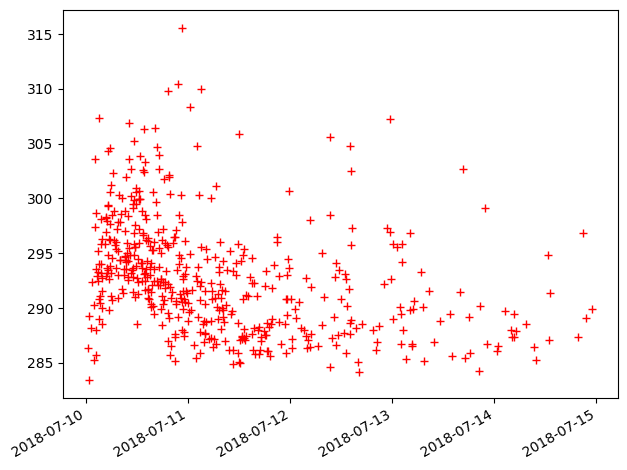

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

selection = df_event[(df_event['origin_date'] > "2018-07-10") & (df_event['origin_date'] < "2018-07-15")]

# Make sure origin_date is datetime
selection = selection.copy()
selection['origin_date'] = pd.to_datetime(selection['origin_date'])

fig, ax = plt.subplots()
ax.plot(selection["origin_date"], selection['SL'], '+', color='red')

# Format x-axis to show dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.gcf().autofmt_xdate()  # rotate labels to avoid overlap
plt.tight_layout()
plt.show()

In [44]:
selection

,event_id,lat,lon,origin_date,cost,SL
0,47105,-31.601302,58.331807,2018-07-12 09:20:48.796598911+00:00,7.502708,298.481320
2,10249,-31.492060,58.051515,2018-07-11 23:32:23.846755981+00:00,8.849529,294.494151
3,75786,-31.503348,58.060860,2018-07-10 03:24:26.057029009+00:00,2.901522,293.991102
4,16395,-31.597066,58.568052,2018-07-13 20:37:44.187216997+00:00,6.794886,290.200136
5,51211,-31.006540,57.765168,2018-07-10 07:33:06.380124092+00:00,2.765386,290.915997
...,...,...,...,...,...,...
676,28652,-31.623633,58.168799,2018-07-10 11:45:00.013772011+00:00,7.526116,293.817826
677,73715,-31.501200,58.050179,2018-07-11 03:27:37.128537892+00:00,5.051878,288.504680
678,53239,-31.808340,58.258997,2018-07-10 19:18:34.048738956+00:00,3.620102,289.555505
679,32760,-31.503333,58.016302,2018-07-11 08:37:32.691509008+00:00,4.445296,291.511911


In [53]:
# PATH = '/media/rsafran/CORSAIR/isc-gem/'
PATH = '/media/rsafran/CORSAIR/isc-ehb/'
# NAME_ISC = 'isc-bulletin_swir_2018.csv'
# NAME_ISC = 'isc-gem-cat.csv'
NAME_ISC = 'USGS_cat.csv' #in ehb file
isc_cnames = ['date','lat','lon','smajax','sminax','strike','q','depth','unc','q.1','mw','unc','q.2','s','mo','fac','mo_auth','mpp','mpr','mrr','mrt','mtp','mtt','str1','dip1','rake1','str2','dip2','rake2','type','eventid']

isc_cat_csv = pd.read_csv(PATH + NAME_ISC, comment='#',header=0,skipinitialspace=True)
# isc_cat_csv['date'] = pd.to_datetime(isc_cat_csv['date'],format='ISO8601', utc=True)
isc_cat_csv['date'] = pd.to_datetime(isc_cat_csv['time'],format='ISO8601', utc=True) #USGS
# isc_cat_csv.loc[:,'date'] = pd.to_datetime(isc_cat_csv.loc[:,'DATE'] + ' ' + isc_cat_csv.loc[:,'TIME'], format='ISO8601', utc=True)

isc_cat_csv.dropna(axis=1, how='any', inplace=True)
isc_cat_csv.rename(columns= {'LAT':'lat', 'LON':'lon','latitude':'lat', 'longitude':'lon', "DEPTH": "depth","MAG":'mw',"mag":'mw', 'EVENTID':'eventid', 'id':'eventid'}, inplace=True)
isc_cat_csv.sort_values('date', inplace=True)
isc_cat_csv = isc_cat_csv[(isc_cat_csv['date'] > "2018-07-10") & (isc_cat_csv['date'] < "2018-07-15" )]

(lat_min, lat_max),(lon_min, lon_max) =(np.float64(-32.22384054054054), np.float64(-31.123840540540606)) ,(np.float64(57.75945945945946), np.float64(58.859459459459394))
isc_cat_csv = isc_cat_csv[(isc_cat_csv['lat'] > lat_min) & (isc_cat_csv['lat'] < lat_max) & (isc_cat_csv['lon'] > lon_min) & (isc_cat_csv['lon'] < lon_max) ]

In [54]:
isc_cat_csv

,time,lat,lon,depth,mw,magType,gap,dmin,rms,net,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,date
769,2018-07-10T03:55:18.730Z,-31.6024,58.1231,10.0,4.9,mb,57,10.605,0.82,us,...,Southwest Indian Ridge,earthquake,5.2,1.9,0.099,32,reviewed,us,us,2018-07-10 03:55:18.730000+00:00
771,2018-07-10T04:40:45.130Z,-31.7009,58.1393,10.0,4.4,mb,133,16.007,0.63,us,...,Southwest Indian Ridge,earthquake,15.7,1.9,0.190,8,reviewed,us,us,2018-07-10 04:40:45.130000+00:00
772,2018-07-10T05:04:22.910Z,-31.6052,57.8023,10.0,4.7,mb,101,10.554,1.08,us,...,Southwest Indian Ridge,earthquake,11.4,1.8,0.134,17,reviewed,us,us,2018-07-10 05:04:22.910000+00:00
773,2018-07-10T05:14:47.600Z,-31.6033,58.1092,10.0,4.8,mb,73,10.604,0.98,us,...,Southwest Indian Ridge,earthquake,5.6,1.8,0.095,34,reviewed,us,us,2018-07-10 05:14:47.600000+00:00
774,2018-07-10T05:28:19.890Z,-31.6404,58.0810,10.0,4.6,mb,122,11.818,0.41,us,...,Southwest Indian Ridge,earthquake,12.3,1.6,0.245,6,reviewed,us,us,2018-07-10 05:28:19.890000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,2018-07-12T01:32:21.360Z,-31.7604,58.2278,10.0,4.6,mb,86,11.987,0.75,us,...,Southwest Indian Ridge,earthquake,10.5,1.9,0.137,16,reviewed,us,us,2018-07-12 01:32:21.360000+00:00
871,2018-07-12T01:41:54.290Z,-31.4108,58.5489,10.0,4.8,mb,122,16.400,0.75,us,...,Southwest Indian Ridge,earthquake,10.1,1.8,0.111,25,reviewed,us,us,2018-07-12 01:41:54.290000+00:00
873,2018-07-12T11:20:34.040Z,-31.5348,58.0240,10.0,4.6,mb,121,10.522,1.19,us,...,Southwest Indian Ridge,earthquake,14.2,1.9,0.183,9,reviewed,us,us,2018-07-12 11:20:34.040000+00:00
876,2018-07-13T04:10:52.930Z,-31.7481,58.4349,10.0,4.7,mb,62,10.806,0.93,us,...,Southwest Indian Ridge,earthquake,6.8,1.8,0.120,21,reviewed,us,us,2018-07-13 04:10:52.930000+00:00


In [55]:
isc_cat_csv.sort_values('date',inplace=True)
selection.sort_values('origin_date', inplace=True)
tmp = pd.merge_asof(
    isc_cat_csv,
    selection,
    left_on='date',
    right_on='origin_date',
    tolerance=pd.Timedelta(seconds=180),
    direction='nearest',

)

In [56]:
tmp.dropna(inplace=True)
print(len(tmp))

71


<Axes: xlabel='SL'>

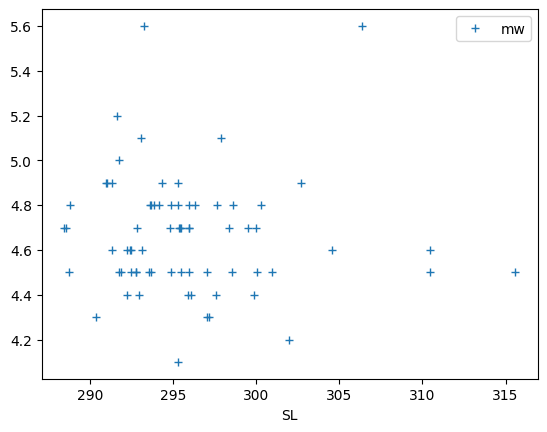

In [57]:
tmp.plot('SL','mw',style='+')

In [58]:
((-32.22384054054054), (-31.123840540540606)) ,((57.75945945945946), (58.859459459459394))

((-32.22384054054054, -31.123840540540606),
 (57.75945945945946, 58.859459459459394))

In [59]:
tmp

,time,lat_x,lon_x,depth,mw,magType,gap,dmin,rms,net,...,status,locationSource,magSource,date,event_id,lat_y,lon_y,origin_date,cost,SL
1,2018-07-10T04:40:45.130Z,-31.7009,58.1393,10.0,4.4,mb,133,16.007,0.63,us,...,reviewed,us,us,2018-07-10 04:40:45.130000+00:00,28306.0,-31.501523,58.077284,2018-07-10 04:41:25.872500896+00:00,4.238441,292.952516
2,2018-07-10T05:04:22.910Z,-31.6052,57.8023,10.0,4.7,mb,101,10.554,1.08,us,...,reviewed,us,us,2018-07-10 05:04:22.910000+00:00,62665.0,-31.564936,58.029019,2018-07-10 05:04:40.639940023+00:00,2.662528,294.817090
3,2018-07-10T05:14:47.600Z,-31.6033,58.1092,10.0,4.8,mb,73,10.604,0.98,us,...,reviewed,us,us,2018-07-10 05:14:47.600000+00:00,53964.0,-31.574470,58.046234,2018-07-10 05:13:32.331444025+00:00,2.499578,296.324300
4,2018-07-10T05:28:19.890Z,-31.6404,58.0810,10.0,4.6,mb,122,11.818,0.41,us,...,reviewed,us,us,2018-07-10 05:28:19.890000+00:00,1459.0,-31.549290,58.083497,2018-07-10 05:26:56.563885927+00:00,5.569583,304.559929
5,2018-07-10T05:33:31.170Z,-31.6520,58.1448,10.0,4.8,mb,78,10.657,0.72,us,...,reviewed,us,us,2018-07-10 05:33:31.170000+00:00,50391.0,-31.579751,58.047522,2018-07-10 05:33:12.646684885+00:00,2.939702,297.647359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2018-07-10T23:28:01.390Z,-31.6472,58.3495,10.0,5.2,mb,52,10.691,1.01,us,...,reviewed,us,us,2018-07-10 23:28:01.390000+00:00,75337.0,-31.736720,58.564771,2018-07-10 23:25:11.779433012+00:00,8.478826,291.592681
81,2018-07-11T02:22:18.970Z,-31.6506,58.2632,10.0,4.8,mb,73,10.678,0.65,us,...,reviewed,us,us,2018-07-11 02:22:18.970000+00:00,73412.0,-31.422800,57.924326,2018-07-11 02:23:37.916956902+00:00,6.624197,300.305030
83,2018-07-11T03:43:22.180Z,-31.6798,58.2623,10.0,4.8,mb,169,10.706,0.56,us,...,reviewed,us,us,2018-07-11 03:43:22.180000+00:00,74462.0,-31.513532,58.034325,2018-07-11 03:42:21.960680008+00:00,2.334837,288.809760
85,2018-07-11T04:07:41.090Z,-31.5952,58.2084,10.0,4.5,mb,79,10.614,0.50,us,...,reviewed,us,us,2018-07-11 04:07:41.090000+00:00,60748.0,-31.636044,58.286769,2018-07-11 04:05:17.552851915+00:00,2.114364,288.708940


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Compute cumulative frequency ---
magnitudes = df_event['SL'].dropna().values  # use your magnitude column

mag_bins = np.arange(magnitudes.min(), magnitudes.max(), 0.1)
cumulative_count = np.array([np.sum(magnitudes >= m) for m in mag_bins])

# Remove zeros (log undefined)
mask = cumulative_count > 1
mag_bins = mag_bins[mask]
cumulative_count = cumulative_count[mask]

# --- 2. Fit a/b values (linear regression on log10) ---
log_N = np.log10(cumulative_count)
coeffs = np.polyfit(mag_bins[:], log_N[:], 1)  # coeffs[0]=b, coeffs[1]=a
b_value = -coeffs[0]
a_value = coeffs[1]

fit_line = np.polyval(coeffs, mag_bins)

# --- 3. Plot ---
fig, ax = plt.subplots()
ax.scatter(mag_bins, cumulative_count, color='red', marker='+', label='Observed')
ax.plot(mag_bins, 10**fit_line, color='blue', label=f'G-R fit: b={b_value:.2f}, a={a_value:.2f}')
plt.yscale('log')
ax.set_xlabel('Magnitude (M)')
ax.set_ylabel('log₁₀ N (cumulative)')
ax.set_title('Gutenberg-Richter Relation')
ax.legend()
plt.tight_layout()
plt.grid()
plt.show()

print(f"a = {a_value:.3f}")
print(f"b = {b_value:.3f}")

NameError: name 'df_event' is not defined